# Agricultural Drought Risk Assessment — Kazakhstan

A workflow adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[DROUGHTS](https://github.com/CLIMAAX/DROUGHTS) GitHub repository for Kazakhstan.

In this workflow we visualise the revenue losses deriving from the reduction in crop
yields due to precipitation scarcity and absence of irrigation. This assessment is
particularly relevant for Kazakhstan's semi-arid regions which are increasingly prone
to prolonged drought periods making artificial irrigation unfeasible, as well as
historically wetter northern oblasts that have not yet implemented artificial irrigation
at large scale but may experience significant declines in precipitation with future
climate change.

### Data Substitutions for Kazakhstan

| Component | Original CLIMAAX | This Adaptation |
|---|---|---|
| Administrative boundaries | NUTS2 (EU GISCO API) | Kazakhstan OSM shapefile |
| Hazard input | EURO-CORDEX yield loss | ISIMIP3b yield loss (from hazard notebook) |
| Crop production | MapSPAM (global) | Unchanged — global dataset |
| Crop aggregated value | GAEZ v5 (global) | Unchanged — global dataset |
| Irrigation availability | GAEZ v5 (global) | Unchanged — global dataset |
| Currency | EUR | USD (Kazakhstan does not use EUR) |

## Load Libraries

In [4]:
import os
import re
import zipfile
from pathlib import Path

import pooch
import pyDataverse.api

import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import shapefile
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Create the Directory Structure

In [5]:
workflow_dir = 'agriculture_workflow'
data_dir     = os.path.join(workflow_dir, 'data')
results_dir  = os.path.join(workflow_dir, 'results')

os.makedirs(workflow_dir, exist_ok=True)
os.makedirs(data_dir,     exist_ok=True)
os.makedirs(results_dir,  exist_ok=True)

## Define the Studied Area

Load Kazakhstan's administrative boundaries from the same local shapefile used in
the hazard workflow. Set `selected_oblast` to a specific oblast name or `None` for
full Kazakhstan — this must match what was used in the hazard notebook so that the
saved yield loss files are found correctly.

In [ ]:
SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)
OBLAST_FIELD = 'oblast_en'

kaz = gpd.read_file(SHAPEFILE_PATH)

selected_oblast = None

if selected_oblast is not None:
    region_gdf  = kaz[kaz[OBLAST_FIELD] == selected_oblast].dissolve()
    region_name = re.sub(r'[^a-zA-Z0-9]', '', selected_oblast)
    region_id   = selected_oblast
else:
    region_gdf  = gpd.GeoDataFrame(geometry=[kaz.geometry.unary_union], crs=kaz.crs)
    region_name = 'Kazakhstan'
    region_id   = 'KAZ'

df          = gpd.GeoSeries.get_coordinates(region_gdf)
coords_user = df.to_numpy()
scale = 0.5
bbox = [
    coords_user[:,0].min() - scale,
    coords_user[:,1].min() - scale,
    coords_user[:,0].max() + scale,
    coords_user[:,1].max() + scale,
]

print(f'Region:       {region_id}')
print(f'Bounding box: {bbox}')

C:\Users\dauzo\AppData\Local\Temp\ipykernel_22376\3368255326.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region_gdf  = gpd.GeoDataFrame(geometry=[kaz.geometry.unary_union], crs=kaz.crs)


Region:       KAZ
Bounding box: [np.float64(45.99321790000005), np.float64(40.06869019999999), np.float64(87.81563360000001), np.float64(55.94217009999994)]


## Import Hazard Data

Load the yield loss outputs produced by the hazard notebook. The `.npy` file contains
the gridded yield loss array and the `.csv` file contains per-pixel coordinates and
metadata. Make sure you have run the hazard notebook first.

In [ ]:
yield_loss_perc = np.load(
    os.path.join(results_dir, f'{region_name}_yield_loss_NUMPY.npy')
)
hazard_df = pd.read_csv(
    os.path.join(results_dir, f'{region_name}_yield_loss_SPREADSHEET.csv')
)

coords_11    = np.stack((hazard_df['lon'].to_numpy(), hazard_df['lat'].to_numpy()), axis=1)
fields_shape = yield_loss_perc.shape[0:2]

print(f'Yield loss array shape: {yield_loss_perc.shape}')
print(f'Grid shape: {fields_shape}')
print(f'Crops in hazard file: {[c for c in hazard_df.columns if c not in ["rcp","start_year","end_year","lat","lon"]]}')

Yield loss array shape: (32, 84, 2)
Grid shape: (32, 84)
Crops in hazard file: ['wheat', 'maize']


### Visualise Hazard Maps

Display the yield loss maps produced by the hazard workflow.

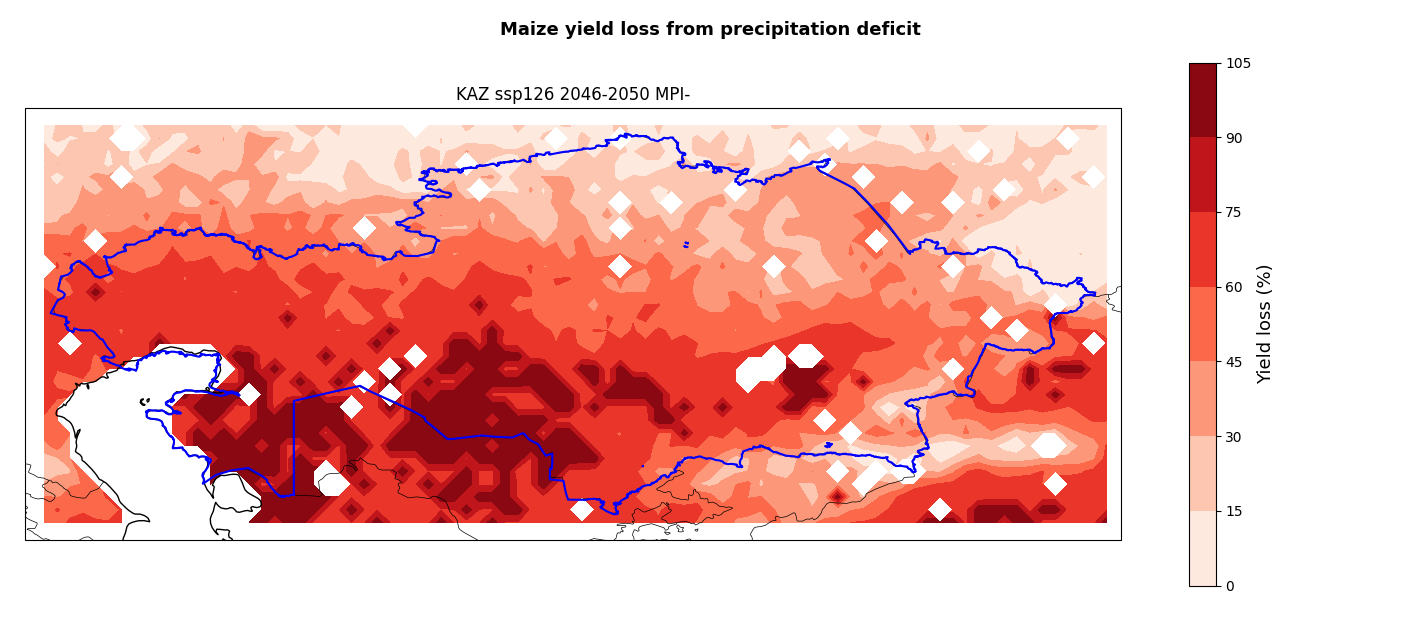

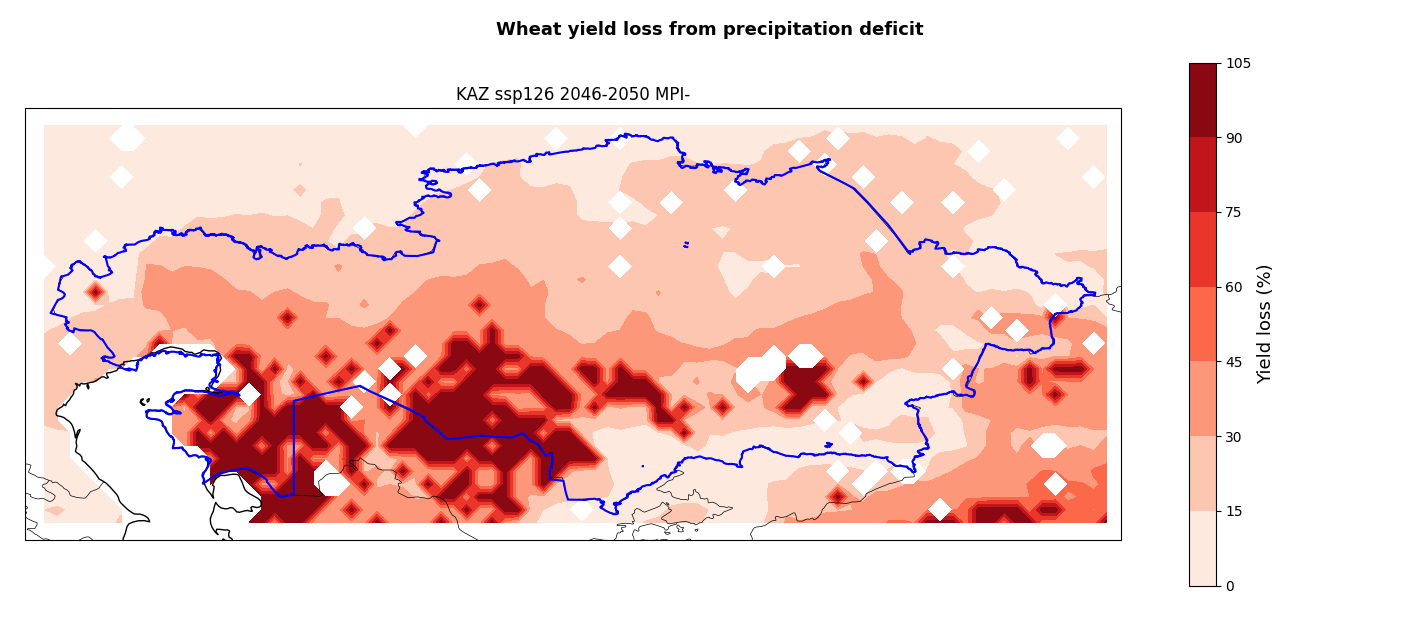

In [8]:
hazard_files = [
    x for x in os.listdir(results_dir)
    if (region_id in x and 'yield_loss.png' in x)
]

for f in hazard_files:
    img = mpimg.imread(os.path.join(results_dir, f), format='png')
    fig = plt.figure(figsize=(14, 6))
    ax  = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    plt.imshow(img)
    plt.show()

## Download and Extract Exposure Data

### 1. Crop Production

Crop production data [ton] for 2020 is retrieved from the
[MapSPAM repository](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/SWPENT)
on Harvard Dataverse. Data is available as global `.tif` rasters at 5 arc-min resolution.
We use data for crops grown under 'high' human inputs and 'all' irrigation modes.
This is a global dataset and applies directly to Kazakhstan.

In [9]:
base_url = 'https://dataverse.harvard.edu/'
api      = pyDataverse.api.NativeApi(base_url)

dataset    = api.get_dataset('doi:10.7910/DVN/SWPENT')
files_list = dataset.json()['data']['latestVersion']['files']
for file in files_list:
    print("ID {id}, Filename: {filename}".format(**file["dataFile"]))

ID 11596408, Filename: Readme_SPAM2020V2r0.txt
ID 11596409, Filename: spam2020V2r0_global_harvested_area.csv.zip
ID 11596412, Filename: spam2020V2r0_global_harvested_area.geotiff.zip
ID 11596414, Filename: spam2020V2r0_global_physical_area.csv.zip
ID 11596411, Filename: spam2020V2r0_global_physical_area.geotiff.zip
ID 11596413, Filename: spam2020V2r0_global_production.csv.zip
ID 11596407, Filename: spam2020V2r0_global_production.geotiff.zip
ID 11596410, Filename: spam2020V2r0_global_yield.csv.zip
ID 11596406, Filename: spam2020V2r0_global_yield.geotiff.zip


In [ ]:
spam_path   = os.path.join(data_dir, 'spam_prod_geotiff.zip')
spam_folder = os.path.join(data_dir, 'spam2020V2r0_global_production')

download_id = '11596407'
data_api    = pyDataverse.api.DataAccessApi(base_url)
response    = data_api.get_datafile(download_id, is_pid=False)

with open(spam_path, 'wb') as f:
    f.write(response.content)

with zipfile.ZipFile(spam_path, 'r') as zObject:
    selected_files = [x for x in zObject.namelist() if '_A.tif' in x]
    zObject.extractall(path=data_dir, members=selected_files)

print(f'Extracted {len(selected_files)} crop production files.')

Extracted 46 crop production files.


In [ ]:
print(", ".join(f.split("_")[-2] for f in selected_files))

BANA, BARL, BEAN, CASS, CHIC, CITR, CNUT, COCO, COFF, COTT, COWP, GROU, LENT, MAIZ, MILL, OCER, OFIB, OILP, ONIO, OOIL, OPUL, ORTS, PIGE, PLNT, PMIL, POTA, RAPE, RCOF, REST, RICE, RUBB, SESA, SORG, SOYB, SUGB, SUGC, SUNF, SWPO, TEAS, TEMF, TOBA, TOMA, TROF, VEGE, WHEA, YAMS


Select the crops to assess. Use the 4-letter SPAM acronyms printed above.
These must correspond to the crop names used in the hazard notebook
(`wheat` → `WHEA`, `maize` → `MAIZ`).

> **Tip for Kazakhstan:** Key crops are `WHEA` (wheat, dominant in the north),
> `MAIZ` (maize), `BARL` (barley), `COTT` (cotton, south), `SUNF` (sunflower).

In [ ]:
spam_list = ['WHEA', 'MAIZ']   

In [ ]:
crops_spam = np.empty((*fields_shape, len(spam_list)), dtype=np.float64)

for a, crop in enumerate(spam_list):
    raster_path = None
    for fname in os.listdir(spam_folder):
        if crop in fname:
            raster_path = os.path.join(spam_folder, fname)
            break
    if raster_path is None:
        raise FileNotFoundError(f'No MapSPAM file found for crop: {crop}')
    with rasterio.open(raster_path) as src:
        crops_spam[:,:,a] = np.reshape(
            [x[0] for x in src.sample(coords_11)], fields_shape
        )

crops_spam[crops_spam < 0] = np.nan

df_spam_all = pd.DataFrame()
for fname in os.listdir(spam_folder):
    if not fname.endswith('.tif'):
        continue
    raster_path = os.path.join(spam_folder, fname)
    with rasterio.open(raster_path) as src:
        df_spam_all[fname] = [x[0] for x in src.sample(coords_11)]

spam_sum = df_spam_all.sum(axis=1).to_numpy(dtype='float64')
spam_sum[spam_sum < 0] = np.nan
spam_sum = spam_sum.reshape(fields_shape)

print(f'Crop production extracted for: {spam_list}')
print(f'Total production grid shape:   {spam_sum.shape}')

Crop production extracted for: ['WHEA', 'MAIZ']
Total production grid shape:   (32, 84)


### 2. Crop Aggregated Value

Aggregated crop value data is sourced from FAO GAEZ v5 for year 2020, expressed in
2015 international dollars (I$). This is a global dataset and applies directly to
Kazakhstan.

In [14]:
crop_value_path = os.path.join(data_dir, 'GAEZ-V5.RES06-VAL.ALL.WST.tif')

pooch.retrieve(
    url='https://storage.googleapis.com/fao-gismgr-gaez-v5-data/DATA/GAEZ-V5/MAPSET/RES06-VAL/GAEZ-V5.RES06-VAL.ALL.WST.tif',
    known_hash='4e333cc83045d61d6fc7538d43438c2eeb0be5e6bc5f6cd7788f383376c91fac',
    path=os.path.dirname(crop_value_path),
    fname=os.path.basename(crop_value_path)
)

'C:\\Users\\dauzo\\Models\\crabook-kazakhstan\\crabook\\notebooks\\workflows\\DROUGHTS\\02_agriculture_drought\\agriculture_workflow\\data\\GAEZ-V5.RES06-VAL.ALL.WST.tif'

In [15]:
with rasterio.open(crop_value_path) as src:
    val_gaez = np.asarray([x[0] for x in src.sample(coords_11)], dtype=np.float64)

val_gaez[val_gaez < 0] = np.nan
val_gaez = val_gaez.reshape(fields_shape)

print(f'GAEZ crop value range: {np.nanmin(val_gaez):.0f} - {np.nanmax(val_gaez):.0f} I$')

GAEZ crop value range: 0 - 42153 I$


## Download and Extract Vulnerability Data — Irrigation Availability

Irrigation availability data is sourced from GAEZ v5 and shows the percentage of
cropland area under irrigation per grid cell for year 2015. In Kazakhstan this is
particularly informative: southern oblasts (Turkistan, Kyzylorda) have high irrigation
shares while the northern wheat belt has very low irrigation penetration, indicating
high vulnerability to precipitation deficits.

In [16]:
irr_avail_path = os.path.join(data_dir, 'GAEZ-V5.LR-IRR.tif')

pooch.retrieve(
    url='https://storage.googleapis.com/fao-gismgr-gaez-v5-data/DATA/GAEZ-V5/MAP/GAEZ-V5.LR-IRR.tif',
    known_hash='28ab7ebd65e037bb7f5440b3a9ad4f803d9d2076c3ca6907d151a02cc56dadde',
    path=os.path.dirname(irr_avail_path),
    fname=os.path.basename(irr_avail_path)
)

'C:\\Users\\dauzo\\Models\\crabook-kazakhstan\\crabook\\notebooks\\workflows\\DROUGHTS\\02_agriculture_drought\\agriculture_workflow\\data\\GAEZ-V5.LR-IRR.tif'

In [17]:
with rasterio.open(irr_avail_path) as src:
    irr_share = np.asarray([x[0] for x in src.sample(coords_11)], dtype=np.float64)

irr_share = irr_share.reshape(fields_shape)

print(f'Irrigation share range: {np.nanmin(irr_share):.1f} - {np.nanmax(irr_share):.1f} %')

Irrigation share range: 0.0 - 100.0 %


## Data Processing

To determine the economic value per pixel of the studied crops and estimate revenue
losses, we:

1. Define the share of total crop production represented by the studied crops
2. Multiply total revenue per pixel by that share to get per-crop revenue (USD/cell)
3. Multiply per-crop revenue by the yield loss from the hazard workflow (USD/cell)

> **Note on currency:** The original CLIMAAX workflow converts to EUR. Since Kazakhstan
> uses KZT (Kazakhstani Tenge), results are kept in USD (I$) here. Multiply by the
> current KZT/USD exchange rate if local currency is preferred.

In [ ]:
crop_prod_fraction = crops_spam / spam_sum[:,:,None]

rev_per_pixel_crop = val_gaez[:,:,None] * crop_prod_fraction

revenue_loss_usd = rev_per_pixel_crop * yield_loss_perc / 100.

print('Revenue loss calculation complete.')
print(f'Output shape: {revenue_loss_usd.shape}  (lat x lon x crops)')

Revenue loss calculation complete.
Output shape: (32, 84, 2)  (lat x lon x crops)


C:\Users\dauzo\AppData\Local\Temp\ipykernel_22376\3749127682.py:2: RuntimeWarning: invalid value encountered in divide
  crop_prod_fraction = crops_spam / spam_sum[:,:,None]


## Plotting the Results

The maps below show the revenue loss per grid cell for the studied crops in the
absence of irrigation (red shading), combined with the share of cropland already
under irrigation (hatching). The hatching serves as a proxy for vulnerability:
areas with low irrigation coverage and high yield loss are most at risk.

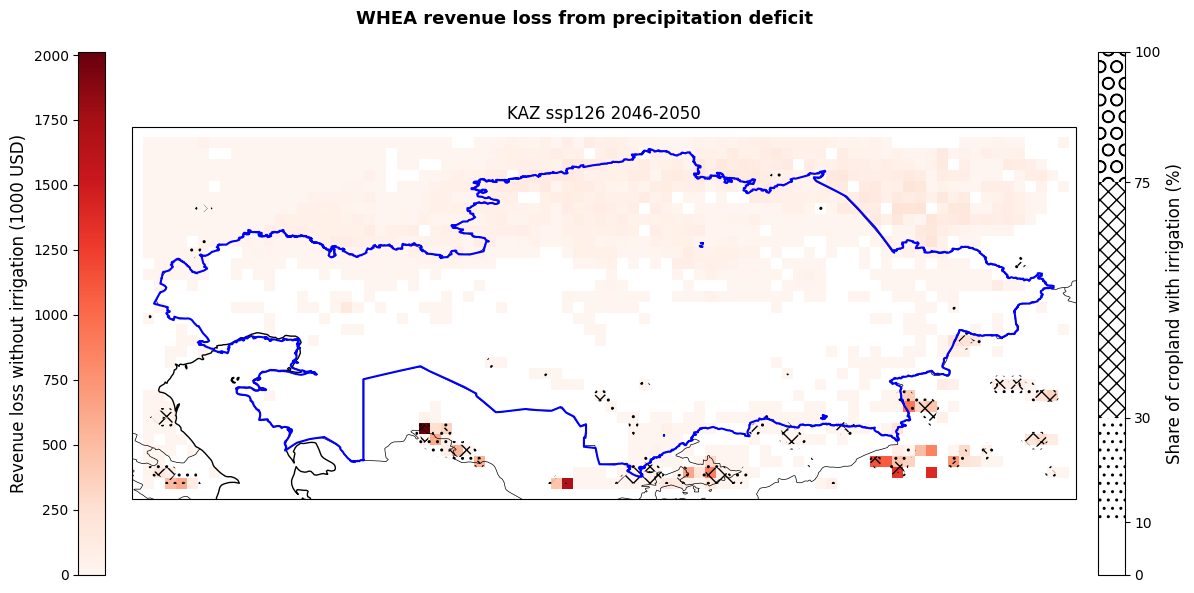

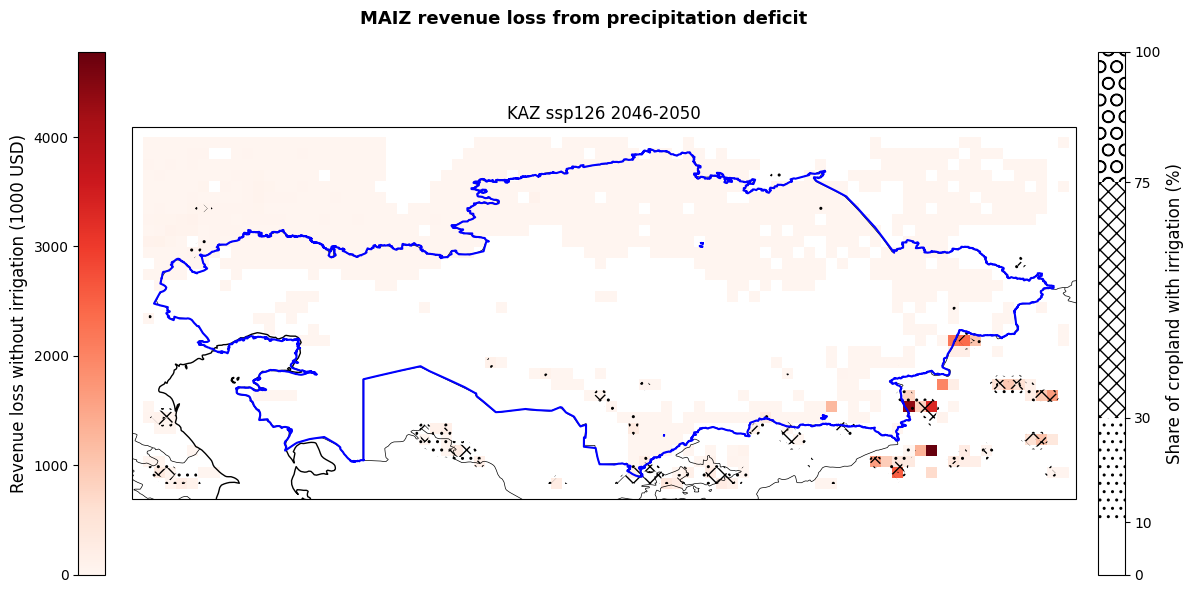

In [ ]:
rcp    = hazard_df['rcp'][0]
ystart = hazard_df['start_year'][0]
yend   = hazard_df['end_year'][0]
zoom   = 0.5

lon_plot  = hazard_df['lon'].to_numpy().reshape(fields_shape)
lat_plot  = hazard_df['lat'].to_numpy().reshape(fields_shape)
irr_levels = np.array([0, 10, 30, 75, 100])


def plot_boundary(ax):
    sf = shapefile.Reader(f'{data_dir}/{region_name}')
    for shape in sf.shapes():
        parts = list(shape.parts) + [len(shape.points)]
        for j in range(len(parts) - 1):
            pts = shape.points[parts[j]:parts[j+1]]
            x = [p[0] for p in pts]
            y = [p[1] for p in pts]
            ax.plot(x, y, transform=ccrs.PlateCarree(), color='b', linewidth=1.5)


for a in range(len(spam_list)):
    fig, ax = plt.subplots(figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent(
        [bbox[0] - zoom, bbox[2] + zoom, bbox[1] - zoom, bbox[3] + zoom],
        crs=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    revenue_map = ax.pcolormesh(
        lon_plot, lat_plot, revenue_loss_usd[:,:,a],
        cmap='Reds', transform=ccrs.PlateCarree(), zorder=1
    )
    revenue_cbar = fig.colorbar(revenue_map, ax=ax, orientation='vertical',
                                location='left', pad=0.02)
    revenue_cbar.set_label('Revenue loss without irrigation (1000 USD)', fontsize=12)

    irr_map = ax.contourf(
        lon_plot, lat_plot, irr_share,
        colors='none', hatches=['', '..', 'xx', 'O'],
        transform=ccrs.PlateCarree(), levels=irr_levels, zorder=1
    )
    irr_cbar = fig.colorbar(irr_map, ax=ax, orientation='vertical',
                            location='right', pad=0.02, spacing='proportional')
    irr_cbar.set_label('Share of cropland with irrigation (%)', fontsize=12)

    plot_boundary(ax)

    plt.suptitle(
        f'{spam_list[a]} revenue loss from precipitation deficit',
        fontsize=13, fontweight='bold'
    )
    plt.title(f'{region_id} {rcp} {ystart}-{yend}')
    plt.tight_layout()
    plt.savefig(
        os.path.join(results_dir, f'{region_id}_{spam_list[a]}_revenue_loss_USD.png')
    )
    plt.show()

The maps show the potential revenue loss from irrigation deficit in Kazakhstan for the
selected crops, emission scenario and period. Red shading represents the lost
opportunity cost in thousands of USD if crops are grown under rainfed-only conditions.
Hatching shows the share of cropland with existing irrigation systems (2015) as a
proxy for vulnerability to water stress.

Key patterns to expect for Kazakhstan:
- Northern oblasts (Akmola, Kostanay, North Kazakhstan) — high wheat revenue loss,
  low irrigation coverage = highest vulnerability
- Southern oblasts (Turkistan, Kyzylorda) — existing irrigation buffers losses but
  increasing water stress makes irrigation itself less reliable
- Central steppe regions — low crop production so low absolute revenue loss

## Conclusions

In this workflow we learned:
- How to combine ISIMIP3b-based yield loss maps with global crop production and
  value datasets to estimate revenue losses from irrigation deficit in Kazakhstan.
- How to use GAEZ irrigation availability as a proxy for vulnerability, identifying
  the most at-risk oblasts for targeted adaptation investment.
- How the northern wheat belt of Kazakhstan — with minimal irrigation infrastructure
  — faces the highest combined exposure and vulnerability to agricultural drought.

## References

- GAEZ v5 (2021). Global Agro-Ecological Zones. FAO & IIASA. https://www.fao.org/gaez/en/
- MapSPAM (2023). Global Spatially-Disaggregated Crop Production Statistics Data for
  2020 Version 2.0. Harvard Dataverse. https://doi.org/10.7910/DVN/SWPENT
- Doorenbos, J. & Kassam, A.H. (1979) Yield response to water. FAO I&D Paper 33.
- ISIMIP (2021). ISIMIP3b bias-adjusted atmospheric climate input data.
  https://doi.org/10.48364/ISIMIP.842396.1